In [1]:
import matplotlib.pyplot as plt
import pandas as pd

#### LOAD ROLES

In [2]:
roles = pd.read_csv("../data/rolle.tsv", sep="\t")
roles.loc[len(roles)] = [-1, 'UNKNOWN']
roles.loc[len(roles)] = [-0, 'REGIE']
roles = roles.rename(columns={'rolleID': 'speaker_id'})
roles = roles.set_index('speaker_id')
roles

,name
speaker_id,
1,"Hitchcock, Erzähler"
2,"Justus Jonas, Erster Detektiv"
3,"Peter Shaw, Zweiter Detektiv"
4,"Bob Andrews, Recherchen und Archiv"
5,"Mr. Fentriss, Schriftsteller"
...,...
2484,Alyssa
2485,Conrad Wilmington
2486,Haley Darlow


#### LOAD COMBINED SCRIPTS

In [3]:
scripts = pd.read_csv('./combine.csv')
scripts = scripts.drop(columns=['Text','Page', 'Episode'])
scripts

,Speaker,speaker_id
0,REGIE,0
1,REGIE,0
2,REGIE,0
3,REGIE,0
4,REGIE,0
...,...,...
229028,Justus,2
229029,REGIE,0
229030,Peter,3
229031,Justus,2


#### GROUP BY SPEAKER ID AND COUNT

In [4]:
speaker_counts = scripts.groupby(by='speaker_id').count()
speaker_counts = speaker_counts.rename(columns={'Speaker': 'count'})
speaker_counts

,count
speaker_id,
-1,16288
0,20298
1,137
2,58718
3,33034
...,...
2447,97
2469,2
2472,10


#### JOIN AND ADD REAL NAMES

In [5]:
speaker_counts = speaker_counts.join(roles, how='left', on='speaker_id')
speaker_counts = speaker_counts.sort_values(by='count', ascending=False)
speaker_counts

,count,name
speaker_id,,
2,58718,"Justus Jonas, Erster Detektiv"
4,35571,"Bob Andrews, Recherchen und Archiv"
3,33034,"Peter Shaw, Zweiter Detektiv"
0,20298,REGIE
-1,16288,UNKNOWN
...,...,...
330,1,Sears
994,1,Gehilfe
334,1,Sekretärin


#### VISUALISE

In [9]:
speaker_counts.head(15)


,count,name
speaker_id,,
2,58718,"Justus Jonas, Erster Detektiv"
4,35571,"Bob Andrews, Recherchen und Archiv"
3,33034,"Peter Shaw, Zweiter Detektiv"
0,20298,REGIE
-1,16288,UNKNOWN
574,14088,Erzähler
436,1596,Inspektor Cotta
13,1045,Tante Mathilda
567,739,Clarissa Franklin


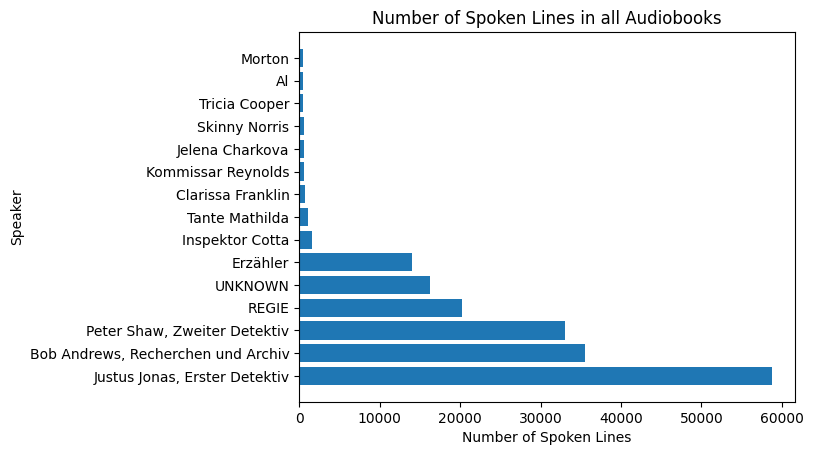

In [7]:
speaker_counts.head()['name']
plt.barh(list(speaker_counts.head(15)['name']), speaker_counts.head(15)['count'])

plt.title('Number of Spoken Lines in all Audiobooks')
plt.xlabel('Number of Spoken Lines')
plt.ylabel('Speaker')
plt.show()

#### List names UNKNOWN

In [8]:
unknowns = scripts.where(
    scripts['speaker_id']==-1
).groupby(
    by='Speaker'
).count().rename(
    columns={'speaker_id' : 'count'}
).sort_values(by='count', ascending=False)
unknowns

,count
Speaker,
Kenneth O'Ryan,286
Jeremy,202
Joan,188
Kommissarin,180
Grace,170
...,...
Vanessa Goldstein,1
Wrenwick,1
Wick Hamil,1
